Waiting for user to select: Step 1: Select WALL Image...
Waiting for user to select: Step 2: Select POSTER Image...
✅ Found 1 marker(s). Using ID: 0


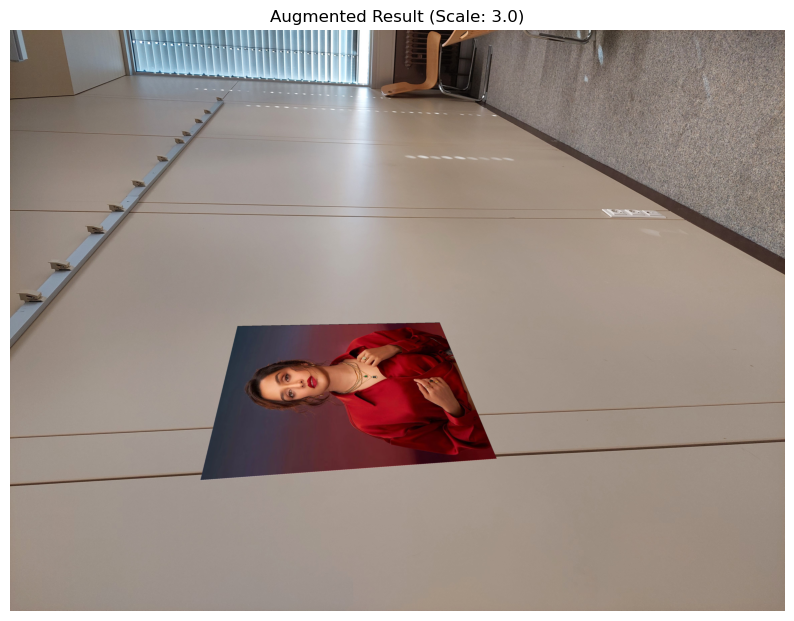

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import sys

# --- 1. GUI FILE SELECTION FUNCTIONS ---
def select_image_file(prompt):
    """Opens a system window to select an image file."""
    # Create a hidden Tkinter root window
    root = tk.Tk()
    root.withdraw() 
    
    print(f"Waiting for user to select: {prompt}...")
    
    # Open the file dialog
    file_path = filedialog.askopenfilename(
        title=prompt,
        filetypes=[("Images", "*.jpg *.jpeg *.png *.bmp *.webp")]
    )
    
    root.destroy() # Close the tkinter instance
    return file_path

# --- 2. CONFIGURATION ---
# SCALE: 1.0 = Same width as marker. 3.0 = 3x wider.
SCALE = 3.0 

# OFFSET: (0,0) is centered on the marker.
# (0, -1.0) moves the poster UP by one marker height.
OFFSET_X = 0.0   
OFFSET_Y =0.0    

# --- 3. THE MATH HELPER ---
def get_expanded_corners(marker_corners, scale, off_x, off_y):
    """
    Calculates where the corners of the big poster should land on the wall.
    """
    # Define the marker as a standard 1x1 square
    unit_marker = np.float32([[0,0], [1,0], [1,1], [0,1]])

    # Calculate the perspective matrix from 1x1 square -> slanted marker on wall
    grid_matrix = cv2.getPerspectiveTransform(unit_marker, marker_corners)

    
    # Calculate logical coordinates based on scale/offset
    radius = scale / 2.0
    center_x = 0.5 + off_x
    center_y = 0.5 + off_y
    
    poster_logical_corners = np.float32([
        [center_x - radius, center_y - radius], # Top-Left
        [center_x + radius, center_y - radius], # Top-Right
        [center_x + radius, center_y + radius], # Bottom-Right
        [center_x - radius, center_y + radius]  # Bottom-Left
    ]).reshape(-1, 1, 2)

    # Transform these logical points to actual pixel coordinates on the wall image
    expanded_pixels = cv2.perspectiveTransform(poster_logical_corners, grid_matrix)
    return expanded_pixels

# --- 4. MAIN EXECUTION ---
if __name__ == "__main__":
    # A. Select Files using GUI
    wall_path = select_image_file("Step 1: Select WALL Image")
    if not wall_path:
        print("❌ Selection cancelled. Exiting.")
        sys.exit()

    poster_path = select_image_file("Step 2: Select POSTER Image")
    if not poster_path:
        print("❌ Selection cancelled. Exiting.")
        sys.exit()

    # B. Load Images
    wall_img = cv2.imread(wall_path)
    poster_img = cv2.imread(poster_path)

    if wall_img is None or poster_img is None:
        print("❌ Error: Could not read image files.")
        sys.exit()

    # C. Detect Marker
    gray = cv2.cvtColor(wall_img, cv2.COLOR_BGR2GRAY)
    
    # Using generic dictionary (Common: 6x6_250)
    # If detection fails, try changing this to DICT_4X4_50 or DICT_5X5_100
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
    detector = cv2.aruco.ArucoDetector(aruco_dict)
    
    corners, ids, rejected = detector.detectMarkers(gray)

    if ids is not None:
        print(f"✅ Found {len(ids)} marker(s). Using ID: {ids[0][0]}")
        
        # 1. Get corners of the FIRST marker found
        marker_corners = corners[0][0]

        # 2. Calculate destination corners on the wall
        dst_corners = get_expanded_corners(marker_corners, SCALE, OFFSET_X, OFFSET_Y)

        # 3. Get source corners of the poster
        h, w = poster_img.shape[:2]
        src_corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]])

        # 4. Warp the poster
        M = cv2.getPerspectiveTransform(src_corners, dst_corners)
        warped_poster = cv2.warpPerspective(poster_img, M, (wall_img.shape[1], wall_img.shape[0]))

        # 5. Blend
        mask = np.zeros_like(wall_img, dtype=np.uint8)
        cv2.fillConvexPoly(mask, dst_corners.astype(int), (255, 255, 255))
        mask_inv = cv2.bitwise_not(mask)
        
        wall_bg = cv2.bitwise_and(wall_img, mask_inv)
        final_result = cv2.add(wall_bg, warped_poster)

        # 6. Show Result
        # Convert BGR (OpenCV) to RGB (Matplotlib)
        plt.figure(figsize=(10,8))
        plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB)) 
        plt.title(f"Augmented Result (Scale: {SCALE})")
        plt.axis('off')
        plt.show()

    else:
        print("❌ No ArUco markers found in the selected wall image.")